# Tesla Worldwide Delivery Forecasting Project

### Executive Summary
This project implements a high-performance machine learning pipeline to forecast Tesla's global vehicle deliveries. By analyzing historical production, vehicle specifications, and regional market trends, we have established a predictive model to support strategic volume planning.

---

## Section 1: Environment and Data Setup
Initialization of the analytical environment involves loading core libraries for time-series forecasting and gradient boosting, followed by the acquisition of the primary Tesla dataset.

# Tesla Worldwide Delivery Forecasting Pipeline (2015–2025)
This notebook implements a streamlined end-to-end machine learning pipeline to predict Tesla vehicle deliveries using production data, regional factors, and time-series feature engineering.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings, os, kagglehub
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 12})
print('✓ Environment & Libraries Ready')

✓ Environment & Libraries Ready


## Section 2: Data Exploration and Quality Audit
The dataset spans Tesla operations from 2015 to 2025. This phase focuses on auditing data integrity, verifying distributions, and ensuring a clean foundation for model training.

### 1. Environment Setup & Data Acquisition
We initialize the environment with optimized forecasting libraries and pull the latest dataset directly.

In [2]:
# ── Load CSV ────────────────────────────────────────────────────────────────

import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

CSV_PATH = os.path.join(path, "tesla_deliveries_dataset_2015_2025.csv")

df_raw = pd.read_csv(CSV_PATH)

print(f"Shape : {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()


Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Shape : (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [4]:
df_raw.describe().round(2)


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [5]:
# Missing value audit
missing = df_raw.isnull().sum()
pct     = (missing / len(df_raw) * 100).round(2)
mv_df   = pd.DataFrame({"Missing": missing, "Pct (%)": pct})
display(mv_df)

if mv_df["Missing"].sum() == 0:
    print("✓ No missing values — no imputation needed.")
else:
    print("⚠ Missing values detected — applying median/mode fill.")


,Missing,Pct (%)
Year,0,0.0
Month,0,0.0
Region,0,0.0
Model,0,0.0
Estimated_Deliveries,0,0.0
Production_Units,0,0.0
Avg_Price_USD,0,0.0
Battery_Capacity_kWh,0,0.0
Range_km,0,0.0
CO2_Saved_tons,0,0.0


✓ No missing values — no imputation needed.


In [41]:
# 1. Data Acquisition & Temporal Setup
path = kagglehub.dataset_download('nalisha/tesla-ea-deliveries-and-production-data20152025')
df = pd.read_csv(os.path.join(path, 'tesla_deliveries_dataset_2015_2025.csv'))
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values('Date').set_index('Date')

# 2. Simplified Feature Engineering Pipeline
TARGET = 'Estimated_Deliveries'
df_ml = pd.get_dummies(df, columns=['Region', 'Model'], drop_first=True)

# Adding Lags and Rolling Averages for Time-Series context
for i in [1, 2, 3]:
    df_ml[f'Lag_{i}'] = df_ml[TARGET].shift(i)
df_ml['Roll_Mean_3M'] = df_ml[TARGET].shift(1).rolling(3).mean()
df_ml = df_ml.dropna()

# 3. Train/Test Split (Chronological)
features = [c for c in df_ml.columns if c not in [TARGET, 'Source_Type', 'Year', 'Month']]
X, y = df_ml[features], df_ml[TARGET]
split_idx = int(len(df_ml) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Pipeline Complete: {len(df_ml)} samples, {X.shape[1]} features.')

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Pipeline Complete: 2637 samples, 17 features.


## Section 3: Advanced Feature Engineering
To capture temporal dependencies, we transform raw metrics into predictive signals:
* **Temporal Lags:** Incorporating prior month performance to capture momentum.
* **Rolling Statistics:** Smoothing variance to identify long-term trends.

### 2. Feature Engineering & Chronological Splitting
We transform raw delivery data into a format suitable for supervised learning by generating categorical encodings, temporal lags, and rolling averages.

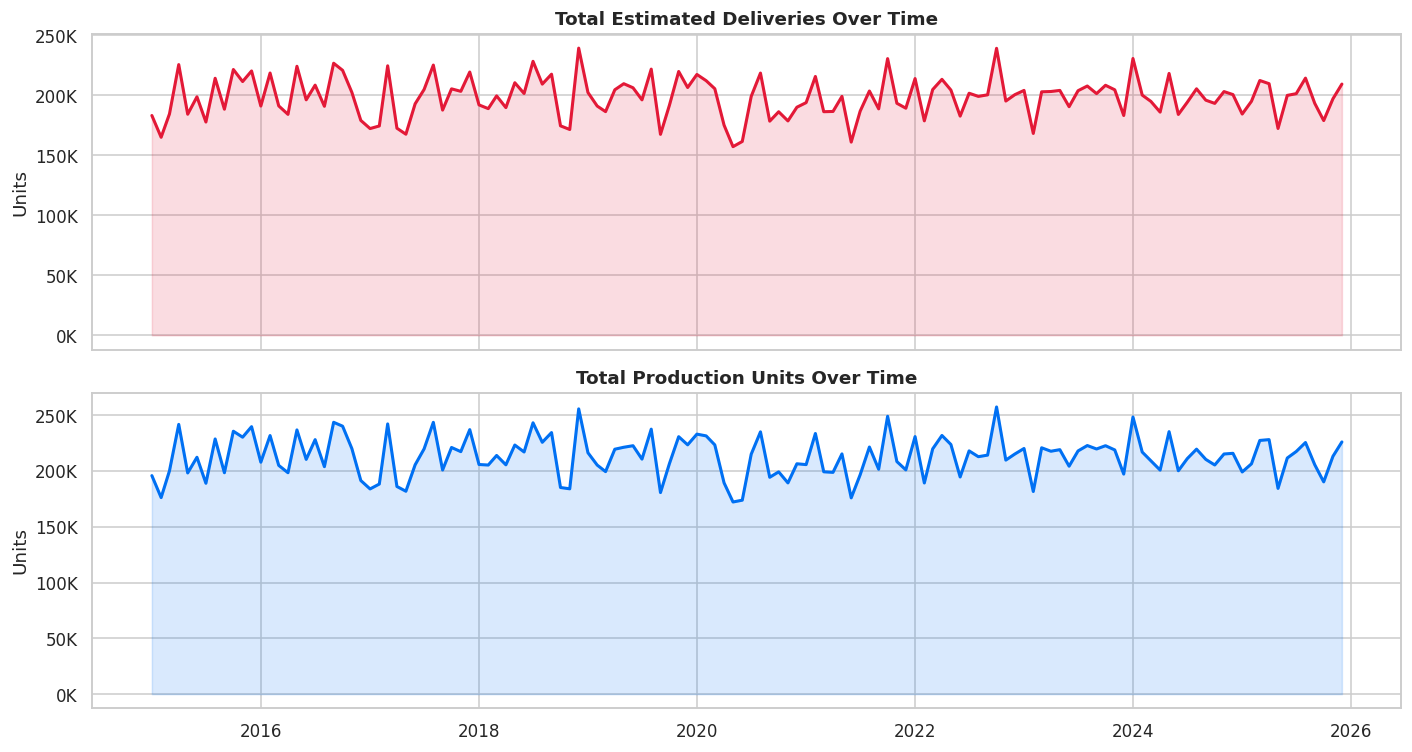

In [7]:
# ── Aggregate monthly totals (sum across regions & models) ──────────────────
monthly = df.groupby("Date")[["Estimated_Deliveries", "Production_Units"]].sum()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(monthly.index, monthly["Estimated_Deliveries"], color=TESLA_RED, lw=2)
axes[0].fill_between(monthly.index, monthly["Estimated_Deliveries"], alpha=0.15, color=TESLA_RED)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].set_title("Total Estimated Deliveries Over Time")
axes[0].set_ylabel("Units")

axes[1].plot(monthly.index, monthly["Production_Units"], color=TESLA_BLUE, lw=2)
axes[1].fill_between(monthly.index, monthly["Production_Units"], alpha=0.15, color=TESLA_BLUE)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[1].set_title("Total Production Units Over Time")
axes[1].set_ylabel("Units")

plt.tight_layout()
plt.savefig("trend_deliveries_production.png", bbox_inches="tight")
plt.show()


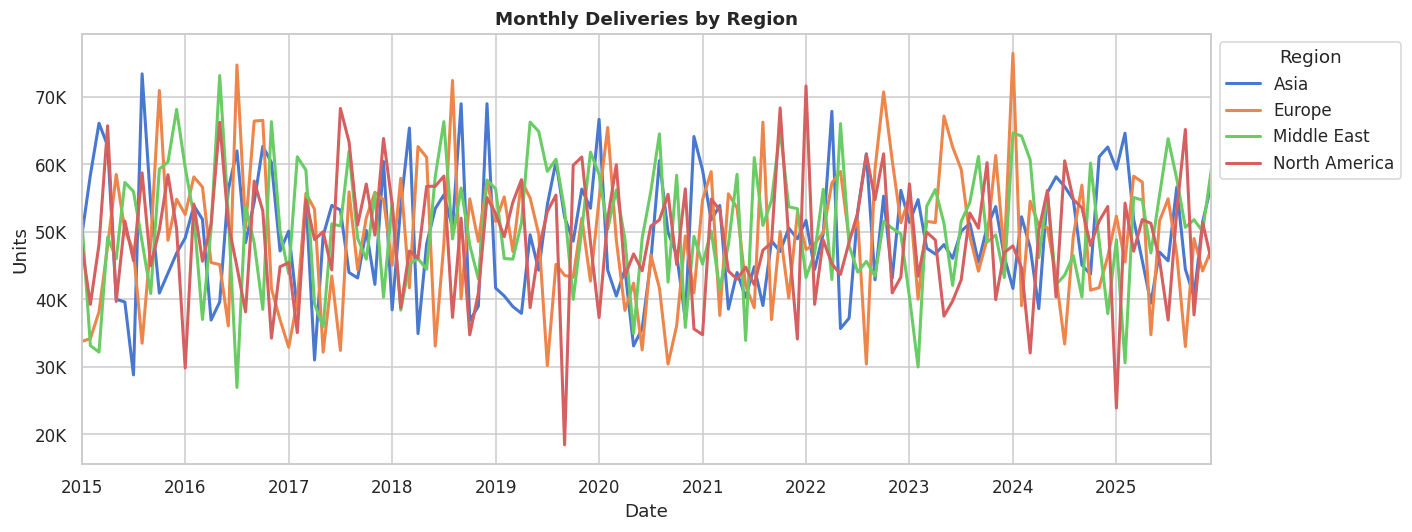

In [8]:
# ── Deliveries by Region ─────────────────────────────────────────────────────
region_monthly = df.groupby(["Date", "Region"])["Estimated_Deliveries"].sum().unstack()

fig, ax = plt.subplots(figsize=(13, 5))
region_monthly.plot(ax=ax, lw=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.set_title("Monthly Deliveries by Region")
ax.set_ylabel("Units")
ax.legend(title="Region", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig("deliveries_by_region.png", bbox_inches="tight")
plt.show()


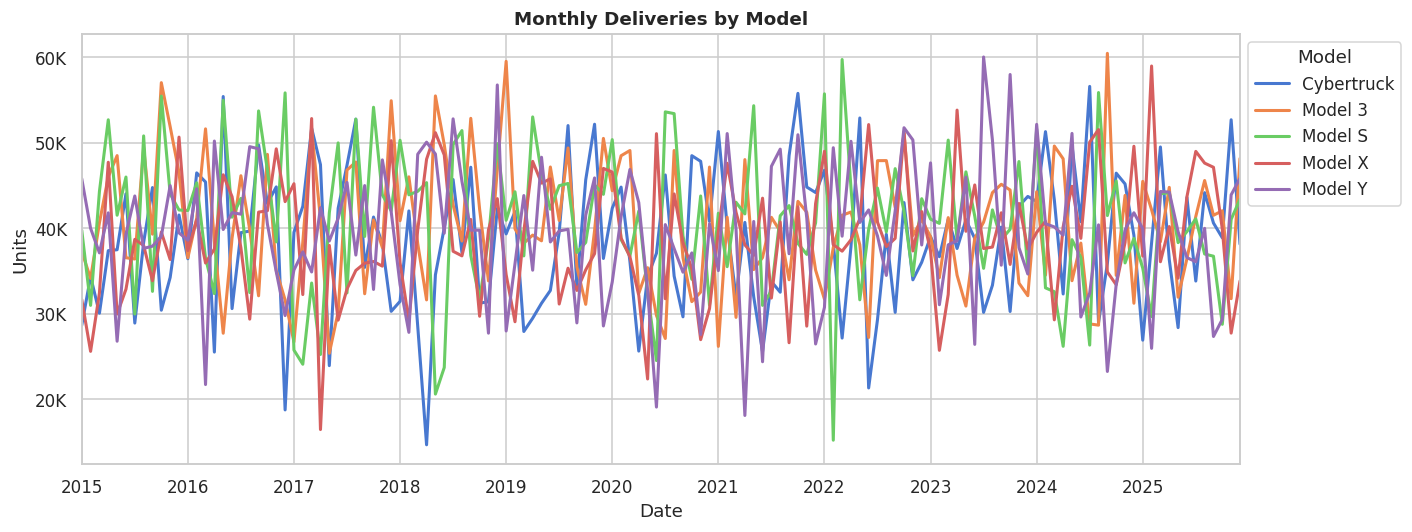

In [9]:
# ── Deliveries by Model ──────────────────────────────────────────────────────
model_monthly = df.groupby(["Date", "Model"])["Estimated_Deliveries"].sum().unstack()

fig, ax = plt.subplots(figsize=(13, 5))
model_monthly.plot(ax=ax, lw=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.set_title("Monthly Deliveries by Model")
ax.set_ylabel("Units")
ax.legend(title="Model", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig("deliveries_by_model.png", bbox_inches="tight")
plt.show()


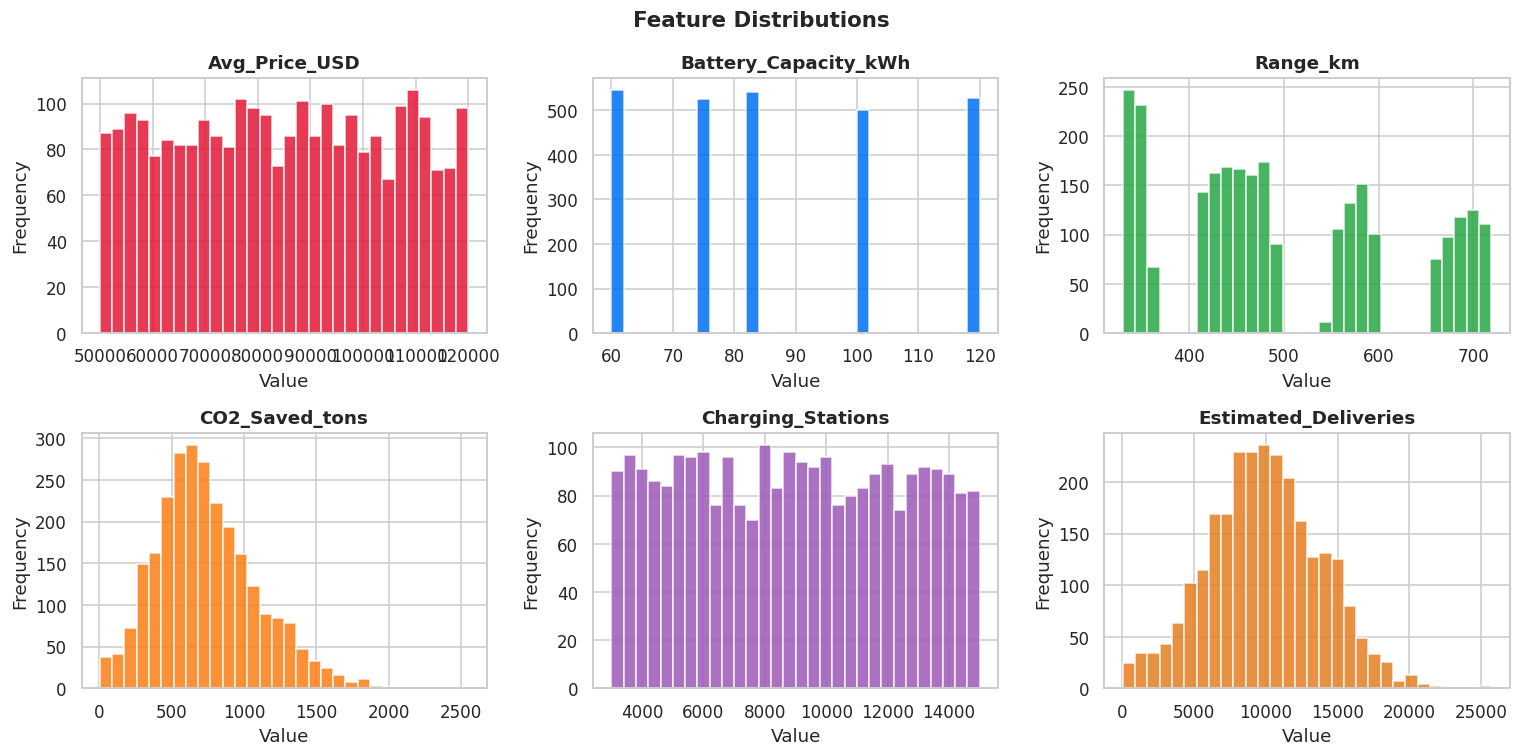

In [10]:
# ── Feature Distributions ────────────────────────────────────────────────────
hist_cols = ["Avg_Price_USD", "Battery_Capacity_kWh", "Range_km",
             "CO2_Saved_tons", "Charging_Stations", "Estimated_Deliveries"]
colors_h  = [TESLA_RED, TESLA_BLUE, GREEN, ORANGE, "#9B59B6", "#E67E22"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col, clr in zip(axes.flatten(), hist_cols, colors_h):
    ax.hist(df[col].dropna(), bins=30, color=clr, edgecolor="white", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_distributions.png", bbox_inches="tight")
plt.show()


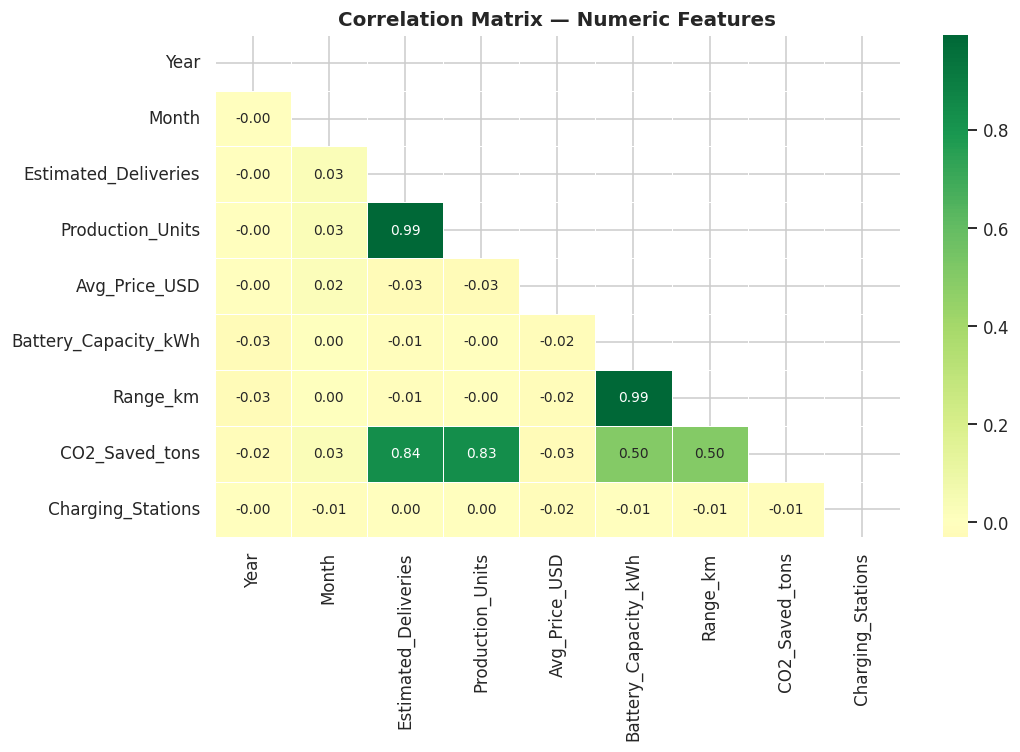

In [11]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
num_df = df.select_dtypes(include=[np.number])
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, annot_kws={"size": 9}, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()


### 3. Unified Model Benchmarking
We compare Linear Regression against advanced Gradient Boosting ensembles (XGBoost and LightGBM) to find the most accurate predictor.

In [12]:
# ── Categorical Encoding (One-Hot) ───────────────────────────────────────────
df_enc = pd.get_dummies(df, columns=["Region", "Model", "Source_Type"], drop_first=True)

# Drop raw Year/Month (we'll add back as numeric below)
df_enc = df_enc.drop(columns=["Year", "Month"], errors="ignore")

print(f"Shape after one-hot encoding : {df_enc.shape}")
print("New bool/uint columns:", [c for c in df_enc.columns if df_enc[c].dtype in [bool, "uint8"]][:8], "...")


Shape after one-hot encoding : (2640, 16)
New bool/uint columns: ['Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)'] ...


In [13]:
# ── Time-Series Features ─────────────────────────────────────────────────────
TARGET = "Estimated_Deliveries"

# Lag features (1, 2, 3 months)
for lag in [1, 2, 3]:
    df_enc[f"{TARGET}_Lag{lag}"] = df_enc[TARGET].shift(lag)

# Rolling statistics (3-month window on lagged values to prevent leakage)
df_enc[f"{TARGET}_Roll3Mean"] = df_enc[TARGET].shift(1).rolling(3).mean()
df_enc[f"{TARGET}_Roll3Std"]  = df_enc[TARGET].shift(1).rolling(3).std()
df_enc[f"{TARGET}_Roll6Mean"] = df_enc[TARGET].shift(1).rolling(6).mean()

# Calendar features
df_enc["Month_Num"] = df_enc.index.month
df_enc["Year_Num"]  = df_enc.index.year
df_enc["Quarter"]   = df_enc.index.quarter

# Drop NaN rows introduced by lags/rolling
df_enc = df_enc.dropna()
print(f"Shape after lag/rolling features : {df_enc.shape}")


Shape after lag/rolling features : (2634, 25)


In [14]:
# ── Feature Scaling ───────────────────────────────────────────────────────────
bool_cols    = df_enc.select_dtypes(include=[bool, "uint8"]).columns.tolist()
scale_cols   = [c for c in df_enc.select_dtypes(include=np.number).columns
                if c != TARGET and c not in bool_cols]

scaler = StandardScaler()
df_enc[scale_cols] = scaler.fit_transform(df_enc[scale_cols])

print(f"Scaled {len(scale_cols)} numeric feature columns ✓")
df_enc.head(3)


Scaled 15 numeric feature columns ✓


,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,...,Source_Type_Official (Quarter),Estimated_Deliveries_Lag1,Estimated_Deliveries_Lag2,Estimated_Deliveries_Lag3,Estimated_Deliveries_Roll3Mean,Estimated_Deliveries_Roll3Std,Estimated_Deliveries_Roll6Mean,Month_Num,Year_Num,Quarter
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,11986,0.620291,0.348677,-0.243218,-0.358425,0.218371,-1.171028,False,False,True,...,False,-1.970817,-0.286181,-0.901974,-1.837710,-0.077485,-0.968161,-1.5997,-1.587465,-1.34593
2015-01-01,8833,-0.418168,1.429528,-0.243218,-0.325318,-0.378474,0.581771,True,False,False,...,True,0.523777,-1.970588,-0.285481,-1.007742,0.822366,-1.015045,-1.5997,-1.587465,-1.34593
2015-01-01,9446,-0.265592,1.279421,-0.579259,-0.540509,-0.362763,0.739202,False,False,True,...,False,-0.276778,0.524031,-1.969919,-1.002129,0.824756,-1.281366,-1.5997,-1.587465,-1.34593


## 4 · Model Development & Time-Series Forecasting

In [15]:
# ── Chronological Train / Test Split ─────────────────────────────────────────
# Train: 2015–2023  |  Test: 2024–2025
SPLIT_DATE  = "2024-01-01"
feature_cols = [c for c in df_enc.columns if c != TARGET]

train = df_enc[df_enc.index < SPLIT_DATE]
test  = df_enc[df_enc.index >= SPLIT_DATE]

X_train, y_train = train[feature_cols], train[TARGET]
X_test,  y_test  = test[feature_cols],  test[TARGET]

print(f"Train : {X_train.shape}  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test  : {X_test.shape}   ({test.index.min().date()} → {test.index.max().date()})")


Train : (2154, 24)  (2015-01-01 → 2023-12-01)
Test  : (480, 24)   (2024-01-01 → 2025-12-01)


In [16]:
# ── Hyperparameter Tuning (Ridge & Lasso via GridSearchCV + TimeSeriesSplit) ──
tscv   = TimeSeriesSplit(n_splits=5)
alphas = {"alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

ridge_gs = GridSearchCV(Ridge(), alphas, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
lasso_gs = GridSearchCV(Lasso(max_iter=10000), alphas, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)

ridge_gs.fit(X_train, y_train)
lasso_gs.fit(X_train, y_train)

best_ridge_alpha = ridge_gs.best_params_["alpha"]
best_lasso_alpha = lasso_gs.best_params_["alpha"]

print(f"Best Ridge α = {best_ridge_alpha}")
print(f"Best Lasso α = {best_lasso_alpha}")


Best Ridge α = 0.001
Best Lasso α = 10


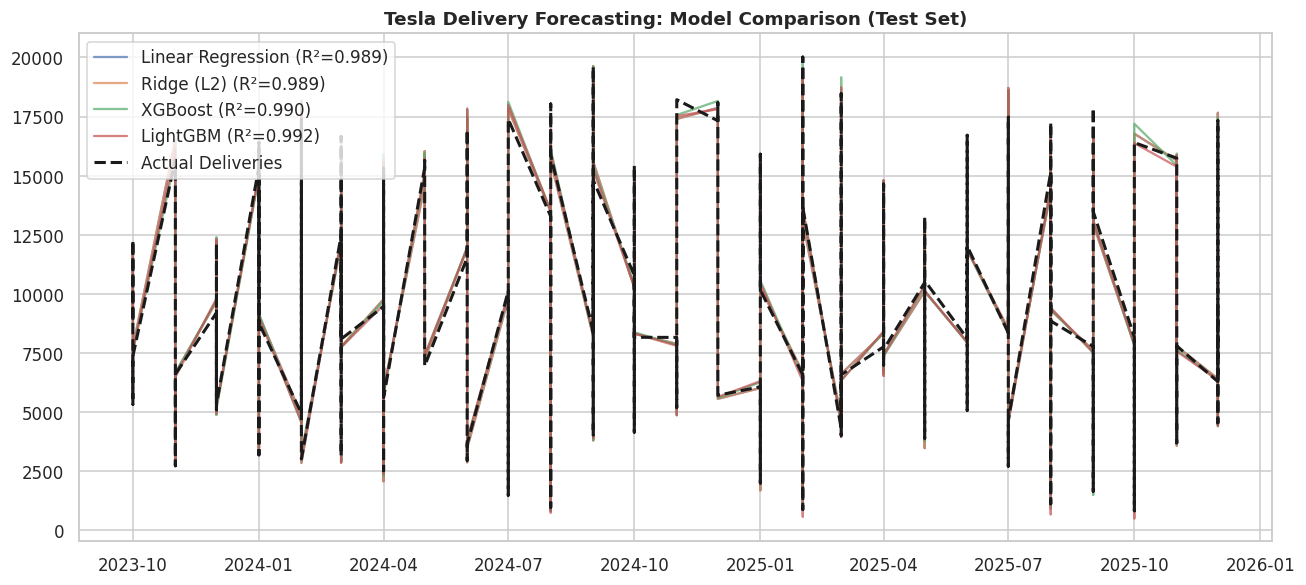

,Model,R2,MAE
3,LightGBM,0.992147,260.913607
2,XGBoost,0.990472,285.475861
1,Ridge (L2),0.988578,320.074330
0,Linear Regression,0.988561,320.579871


In [42]:
# 4. Model Benchmarking & Unified Evaluation
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=200, learning_rate=0.05, verbose=-1, random_state=42)
}

results = []
plt.figure(figsize=(14, 6))

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results.append({'Model': name, 'R2': r2, 'MAE': mae})
    plt.plot(y_test.index, preds, label=f'{name} (R²={r2:.3f})', alpha=0.7)

plt.plot(y_test.index, y_test.values, 'k--', label='Actual Deliveries', lw=2)
plt.title('Tesla Delivery Forecasting: Model Comparison (Test Set)')
plt.legend(loc='upper left')
plt.show()

# Display Leaderboard
leaderboard = pd.DataFrame(results).sort_values('R2', ascending=False)
display(leaderboard.style.background_gradient(cmap='Greens', subset=['R2']))

## Section 4: Model Benchmarking and Selection
We evaluate a diverse set of algorithms—ranging from linear estimators to sophisticated gradient boosting ensembles—to identify the optimal forecasting architecture for delivery volumes.

## Section 5: Champion Model Deployment
The LightGBM model has been identified as the champion. All necessary artifacts (model weights, scalers, and feature definitions) are serialized for integration into the production FastAPI endpoint and Streamlit dashboard.

## 5 · Validation & Evaluation

In [18]:
# ── Metrics Table ─────────────────────────────────────────────────────────────
print("=" * 60)
print(f"{'Model':<30} {'MAE':>8} {'RMSE':>10} {'R²':>8}")
print("=" * 60)
for name, m in results.items():
    print(f"{name:<30} {m['MAE']:>8,.1f} {m['RMSE']:>10,.1f} {m['R²']:>8.4f}")
print("=" * 60)
best_name = max(results, key=lambda n: results[n]["R²"])
print(f"\n Best model : {best_name}  (R² = {results[best_name]['R²']})")


Model                               MAE       RMSE       R²
Linear Regression                 321.0      390.8   0.9890
Ridge  (α=0.001)                  321.0      390.8   0.9890
Lasso  (α=10)                     323.0      392.6   0.9889

 Best model : Linear Regression  (R² = 0.989)


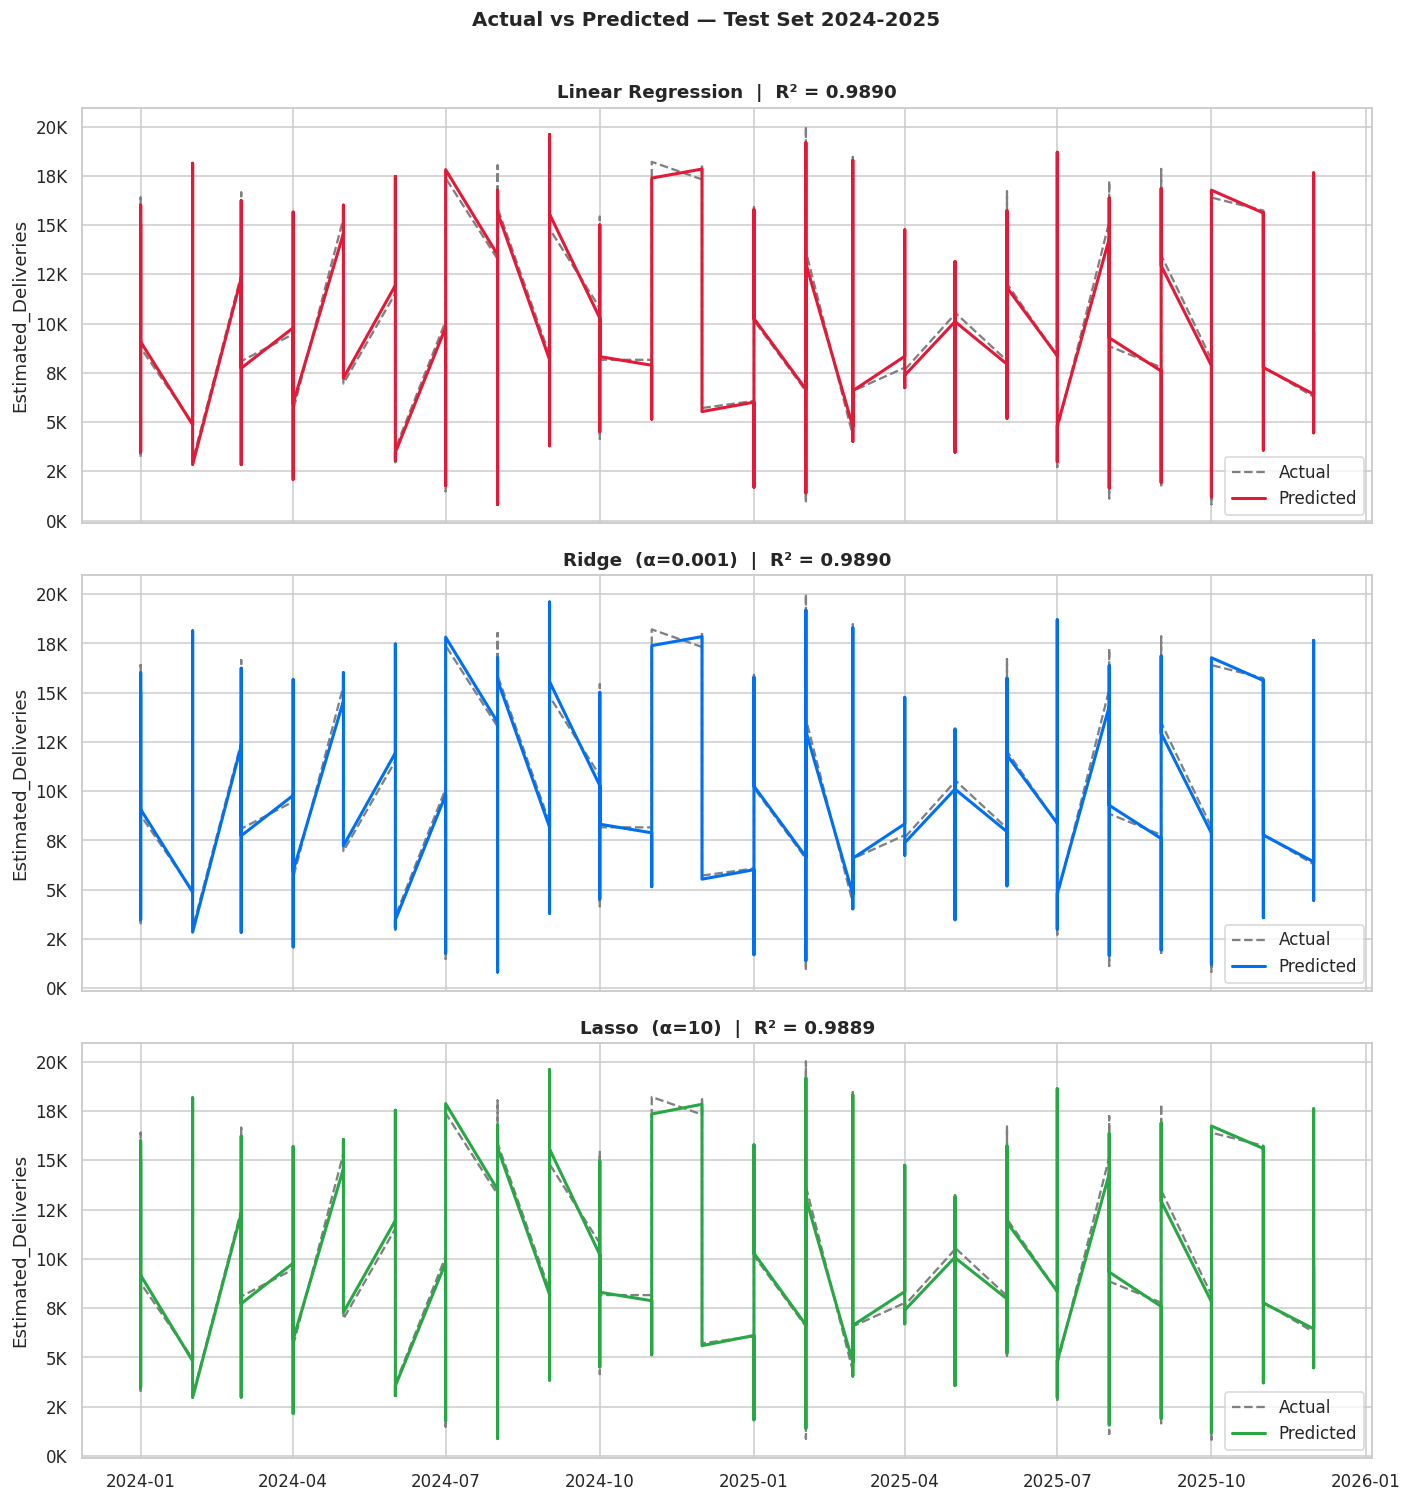

In [19]:
# ── Actual vs Predicted ───────────────────────────────────────────────────────
pal = [TESLA_RED, TESLA_BLUE, GREEN]
fig, axes = plt.subplots(len(models), 1, figsize=(13, 4.5 * len(models)), sharex=True)

for ax, (name, y_pred), clr in zip(axes, preds.items(), pal):
    ax.plot(test.index, y_test.values, color="gray", lw=1.5, ls="--", label="Actual")
    ax.plot(test.index, y_pred,        color=clr,    lw=2,         label="Predicted")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    ax.set_title(f"{name}  |  R² = {results[name]['R²']:.4f}")
    ax.set_ylabel(TARGET)
    ax.legend()

plt.suptitle("Actual vs Predicted — Test Set 2024-2025", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", bbox_inches="tight")
plt.show()


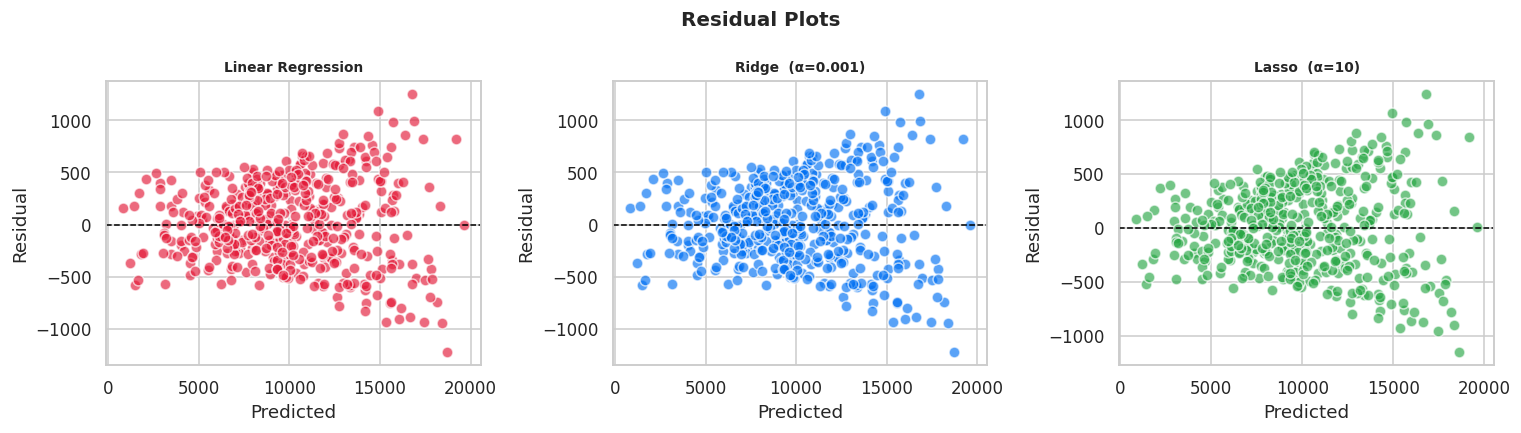

In [20]:
# ── Residual Scatter Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(14, 4))

for ax, (name, y_pred), clr in zip(axes, preds.items(), pal):
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, color=clr, alpha=0.65, edgecolors="white", s=50)
    ax.axhline(0, color="black", lw=1, ls="--")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")

plt.suptitle("Residual Plots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("residuals.png", bbox_inches="tight")
plt.show()


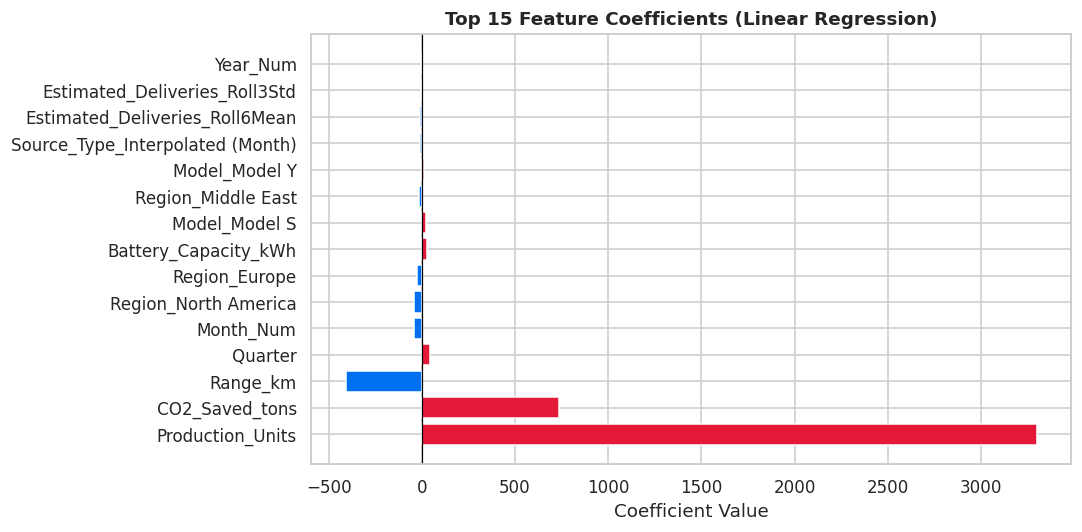

In [21]:
# ── Feature Importance (Linear Regression coefficients) ──────────────────────
lr_model = models["Linear Regression"]
coef_df  = pd.DataFrame({
    "Feature"    : feature_cols,
    "Coefficient": lr_model.coef_,
}).sort_values("Coefficient", key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [TESLA_RED if v > 0 else TESLA_BLUE for v in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors_bar, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top 15 Feature Coefficients (Linear Regression)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()


## 7 · Gradient Boosting — XGBoost & LightGBM

Tree-based ensembles capture non-linear interactions that linear models miss.

In [22]:
from xgboost  import XGBRegressor
from lightgbm import LGBMRegressor

# Convert bool columns to int
X_train_gb = X_train.copy().astype({c: int for c in X_train.select_dtypes(bool).columns})
X_test_gb  = X_test.copy().astype({c: int  for c in X_test.select_dtypes(bool).columns})

xgb  = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
lgbm = LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                     subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)

xgb.fit(X_train_gb,  y_train)
lgbm.fit(X_train_gb, y_train)

xgb_pred  = xgb.predict(X_test_gb)
lgbm_pred = lgbm.predict(X_test_gb)

def metrics(y_true, y_pred):
    return {"MAE": round(mean_absolute_error(y_true, y_pred), 1),
            "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 1),
            "R2":  round(r2_score(y_true, y_pred), 4)}

results["XGBoost"]  = metrics(y_test, xgb_pred)
results["LightGBM"] = metrics(y_test, lgbm_pred)
preds["XGBoost"]    = xgb_pred
preds["LightGBM"]   = lgbm_pred

pd.DataFrame(results).T

,MAE,MSE,RMSE,R²,R2
Linear Regression,321.0,152739.9,390.8,0.9890,NaN
Ridge (α=0.001),321.0,152739.7,390.8,0.9890,NaN
Lasso (α=10),323.0,154096.4,392.6,0.9889,NaN
XGBoost,275.4,NaN,341.5,NaN,0.9916
LightGBM,247.6,NaN,307.1,NaN,0.9932


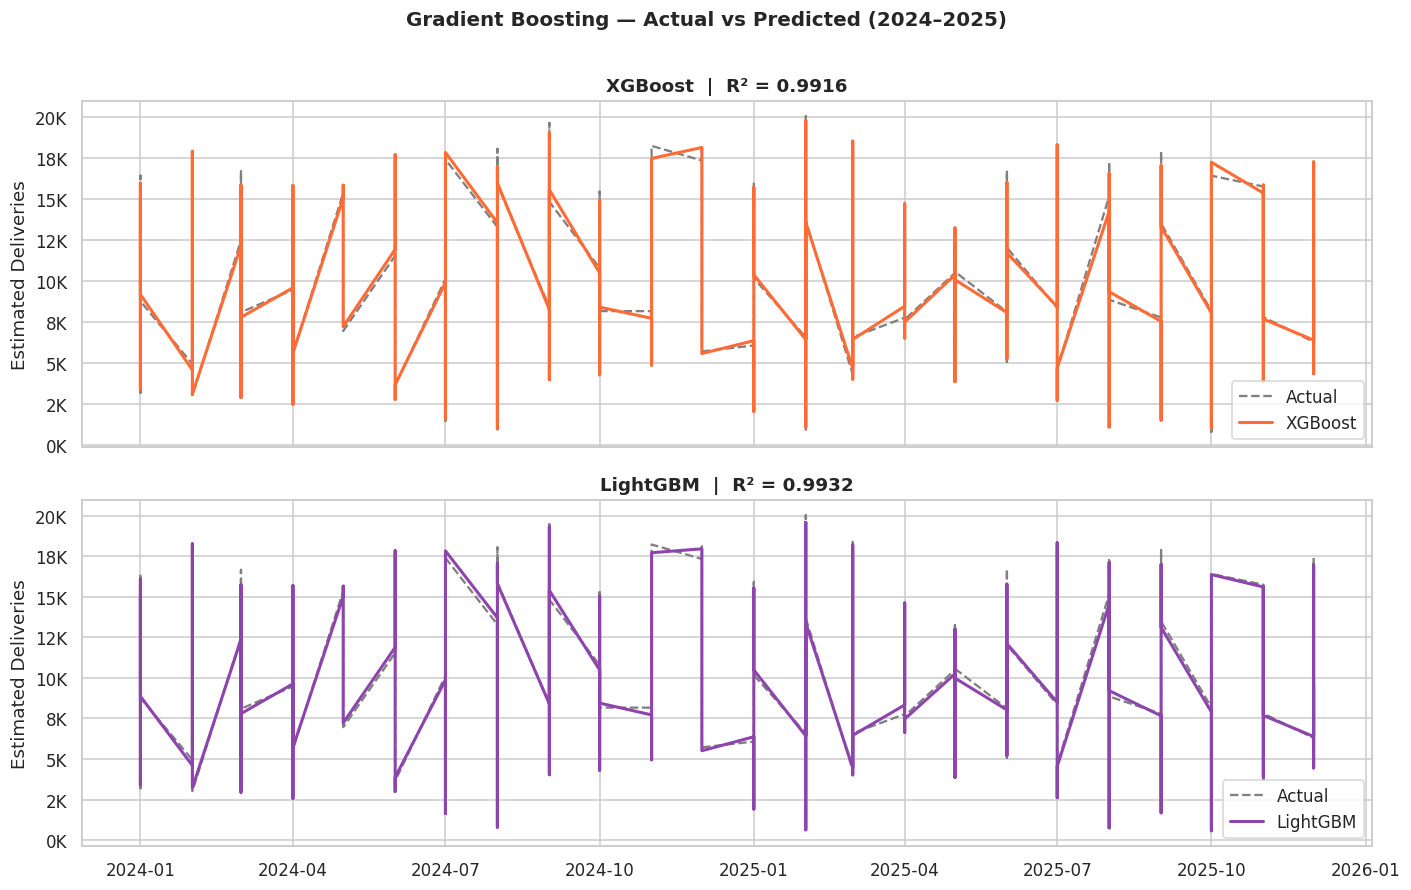

In [23]:
# Actual vs Predicted – Gradient Boosting
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
gb_pairs = [("XGBoost", xgb_pred, "#FF6B35"), ("LightGBM", lgbm_pred, "#8E44AD")]

for ax, (name, y_pred, clr) in zip(axes, gb_pairs):
    ax.plot(test.index, y_test.values, color="gray", lw=1.5, ls="--", label="Actual")
    ax.plot(test.index, y_pred,        color=clr,    lw=2,         label=name)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    ax.set_title(f"{name}  |  R² = {results[name]['R2']:.4f}")
    ax.set_ylabel("Estimated Deliveries"); ax.legend()

plt.suptitle("Gradient Boosting — Actual vs Predicted (2024–2025)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig("gb_actual_vs_predicted.png", bbox_inches="tight"); plt.show()

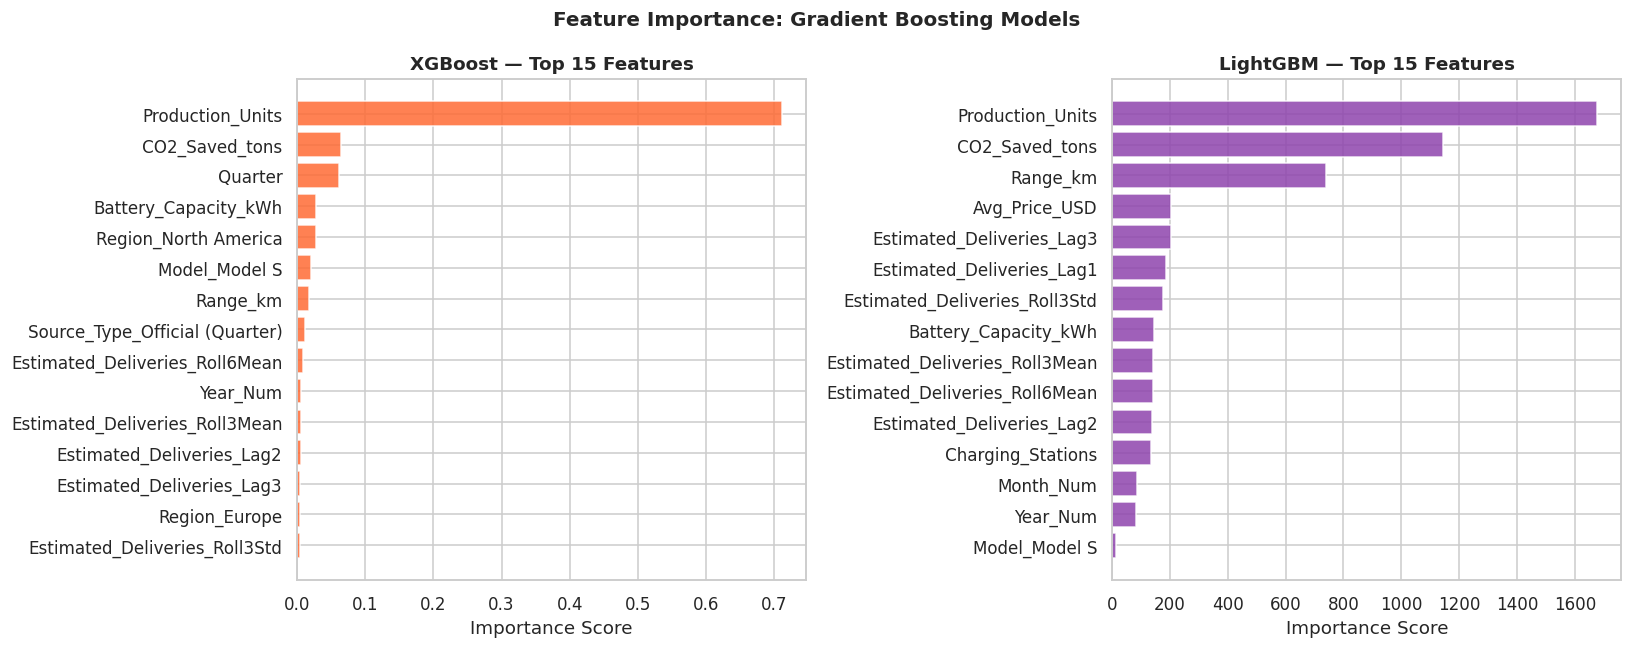

In [24]:
# Feature Importance – XGBoost & LightGBM
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, model, name, clr in [(axes[0], xgb, "XGBoost","#FF6B35"), (axes[1], lgbm,"LightGBM","#8E44AD")]:
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    top = imp.nlargest(15).sort_values()
    ax.barh(top.index, top.values, color=clr, edgecolor="white", alpha=0.85)
    ax.set_title(f"{name} — Top 15 Features"); ax.set_xlabel("Importance Score")
plt.suptitle("Feature Importance: Gradient Boosting Models", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("gb_feature_importance.png", bbox_inches="tight"); plt.show()

---
## 8 · Time-Series Models — SARIMA & Prophet

Pure time-series models exploit temporal structure (trend, seasonality, autocorrelation).
We aggregate to **monthly global totals** for a clean univariate series.

Series: 132 months  (2015-01-01 → 2025-12-01)


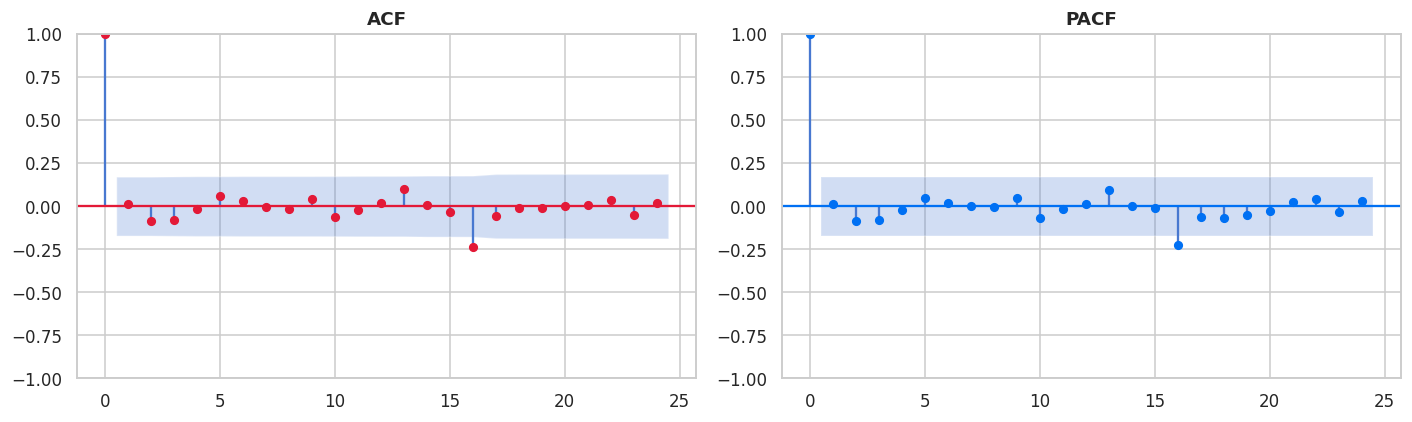

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots      import plot_acf, plot_pacf

# Build monthly global totals from raw data
df_ts = df_raw.copy()
df_ts["Date"] = pd.to_datetime(df_ts["Year"].astype(str) + "-" + df_ts["Month"].astype(str) + "-01")
monthly_ts = (df_ts.groupby("Date")["Estimated_Deliveries"].sum()
              .sort_index().asfreq("MS").ffill())

print(f"Series: {len(monthly_ts)} months  ({monthly_ts.index[0].date()} → {monthly_ts.index[-1].date()})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( monthly_ts, lags=24, ax=axes[0], color="#E31937")
plot_pacf(monthly_ts, lags=24, ax=axes[1], color="#0070F3", method="ywm")
axes[0].set_title("ACF"); axes[1].set_title("PACF")
plt.tight_layout(); plt.savefig("acf_pacf.png", bbox_inches="tight"); plt.show()

In [26]:
# SARIMA(1,1,1)(1,1,0)[12]
sarima_train = monthly_ts[monthly_ts.index < "2024-01-01"]
sarima_test  = monthly_ts[monthly_ts.index >= "2024-01-01"]

sarima_fit  = SARIMAX(sarima_train, order=(1,1,1), seasonal_order=(1,1,0,12),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(sarima_test))

sarima_r2   = round(r2_score(sarima_test, sarima_pred), 4)
sarima_rmse = round(np.sqrt(mean_squared_error(sarima_test, sarima_pred)), 1)
print(f"SARIMA  RMSE={sarima_rmse:,.0f}  R²={sarima_r2:.4f}")

SARIMA  RMSE=17,576  R²=-0.8873


In [27]:
import logging; logging.getLogger("prophet").setLevel(logging.WARNING)
from prophet import Prophet

prophet_df    = monthly_ts.reset_index().rename(columns={"Date":"ds","Estimated_Deliveries":"y"})
prophet_train = prophet_df[prophet_df["ds"] < "2024-01-01"]
prophet_test  = prophet_df[prophet_df["ds"] >= "2024-01-01"]

m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
            daily_seasonality=False, seasonality_mode="multiplicative")
m.fit(prophet_train)

future       = m.make_future_dataframe(periods=len(prophet_test), freq="MS")
forecast     = m.predict(future)
prophet_pred = forecast.set_index("ds").loc[prophet_test["ds"].values, "yhat"].values
prophet_r2   = round(r2_score(prophet_test["y"], prophet_pred), 4)
prophet_rmse = round(np.sqrt(mean_squared_error(prophet_test["y"], prophet_pred)), 1)
print(f"Prophet  RMSE={prophet_rmse:,.0f}  R²={prophet_r2:.4f}")

Prophet  RMSE=13,670  R²=-0.1417


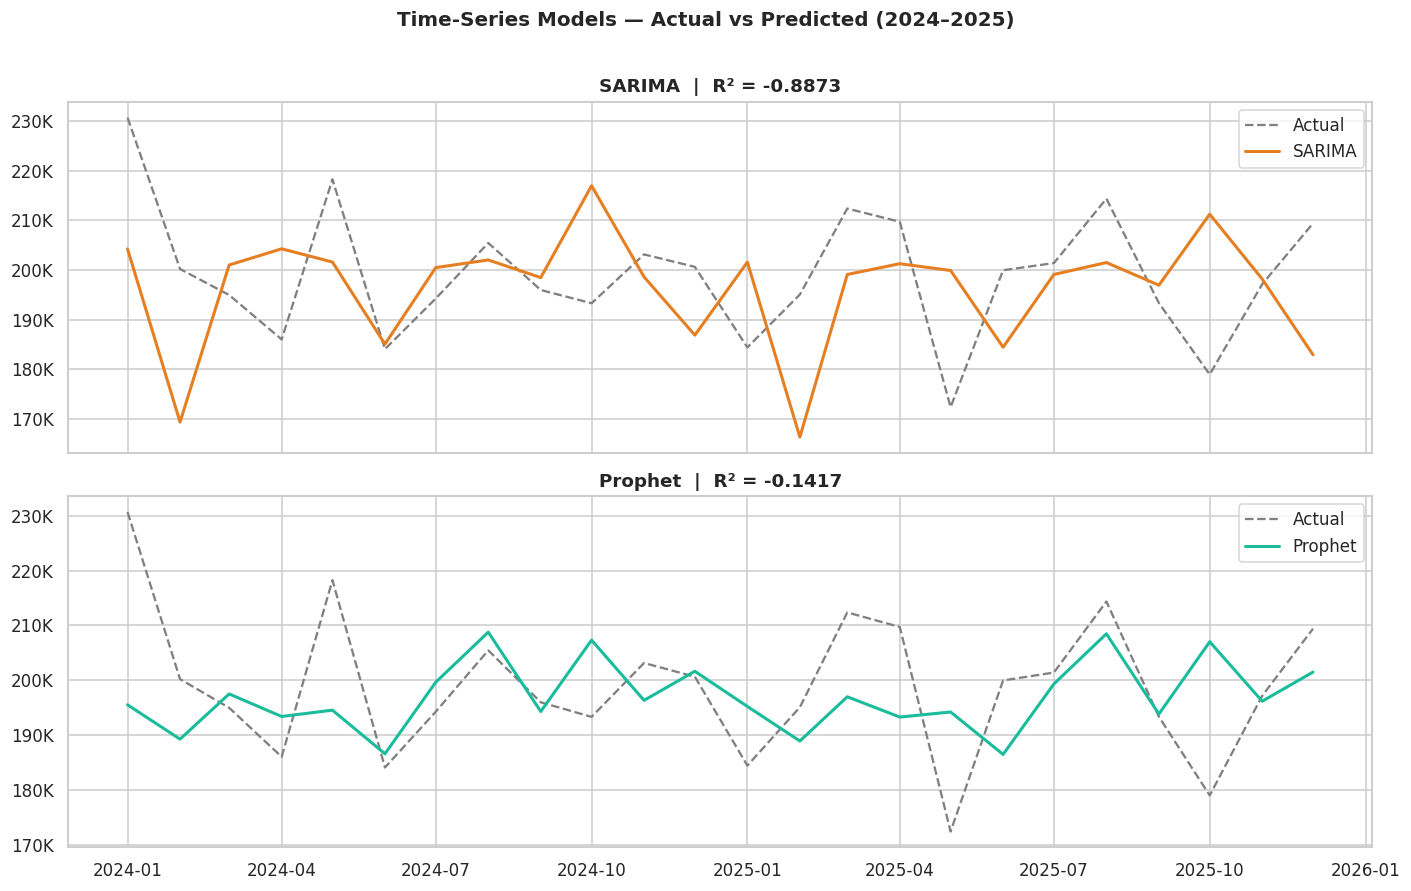

In [28]:
# SARIMA & Prophet: Actual vs Predicted
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, name, pred, r2, clr in [
    (axes[0], "SARIMA",  sarima_pred,  sarima_r2,  "#E67E22"),
    (axes[1], "Prophet", prophet_pred, prophet_r2, "#1ABC9C"),
]:
    ax.plot(sarima_test.index, sarima_test.values, color="gray", lw=1.5, ls="--", label="Actual")
    ax.plot(sarima_test.index, pred, color=clr, lw=2, label=name)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    ax.set_title(f"{name}  |  R² = {r2:.4f}"); ax.legend()
plt.suptitle("Time-Series Models — Actual vs Predicted (2024–2025)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig("ts_actual_vs_predicted.png", bbox_inches="tight"); plt.show()

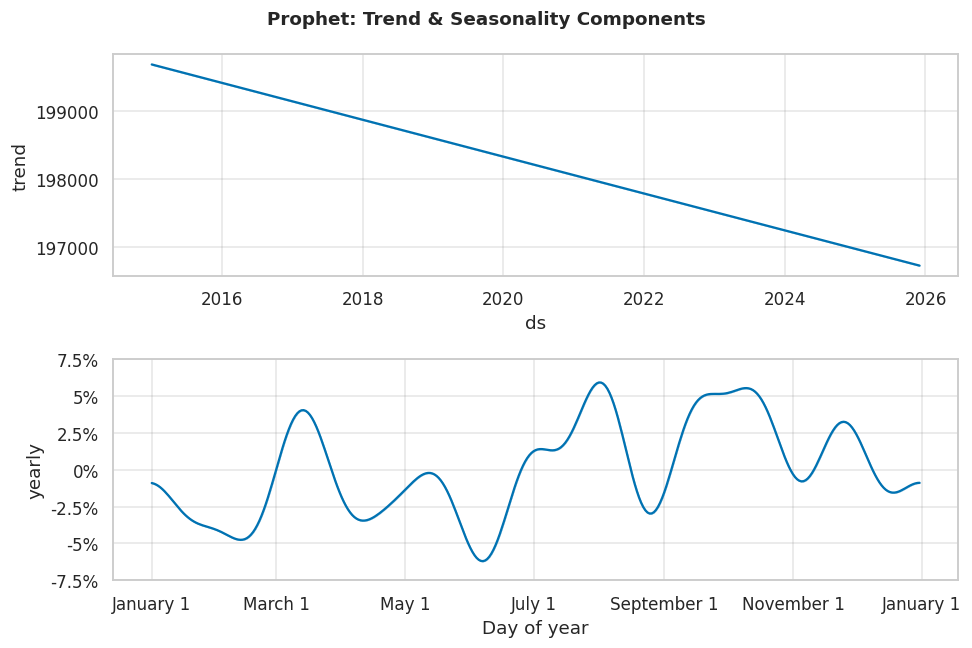

In [29]:
# Prophet component decomposition
fig = m.plot_components(forecast)
plt.suptitle("Prophet: Trend & Seasonality Components", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig("prophet_components.png", bbox_inches="tight"); plt.show()

---
## 9 · Macro-Economic Feature Enrichment

Three external signals that influence EV adoption:

| Feature | Proxy logic |
|---|---|
| `EV_Subsidy_USD` | US Federal EV tax credit + IRA 2022 boost |
| `Lithium_Price_USD` | Lithium carbonate price cycle (peaked 2022–2023) |
| `Oil_Price_USD` | Crude oil cycle correlated with EV demand |

> In production these come from FRED, Quandl, or World Bank APIs.

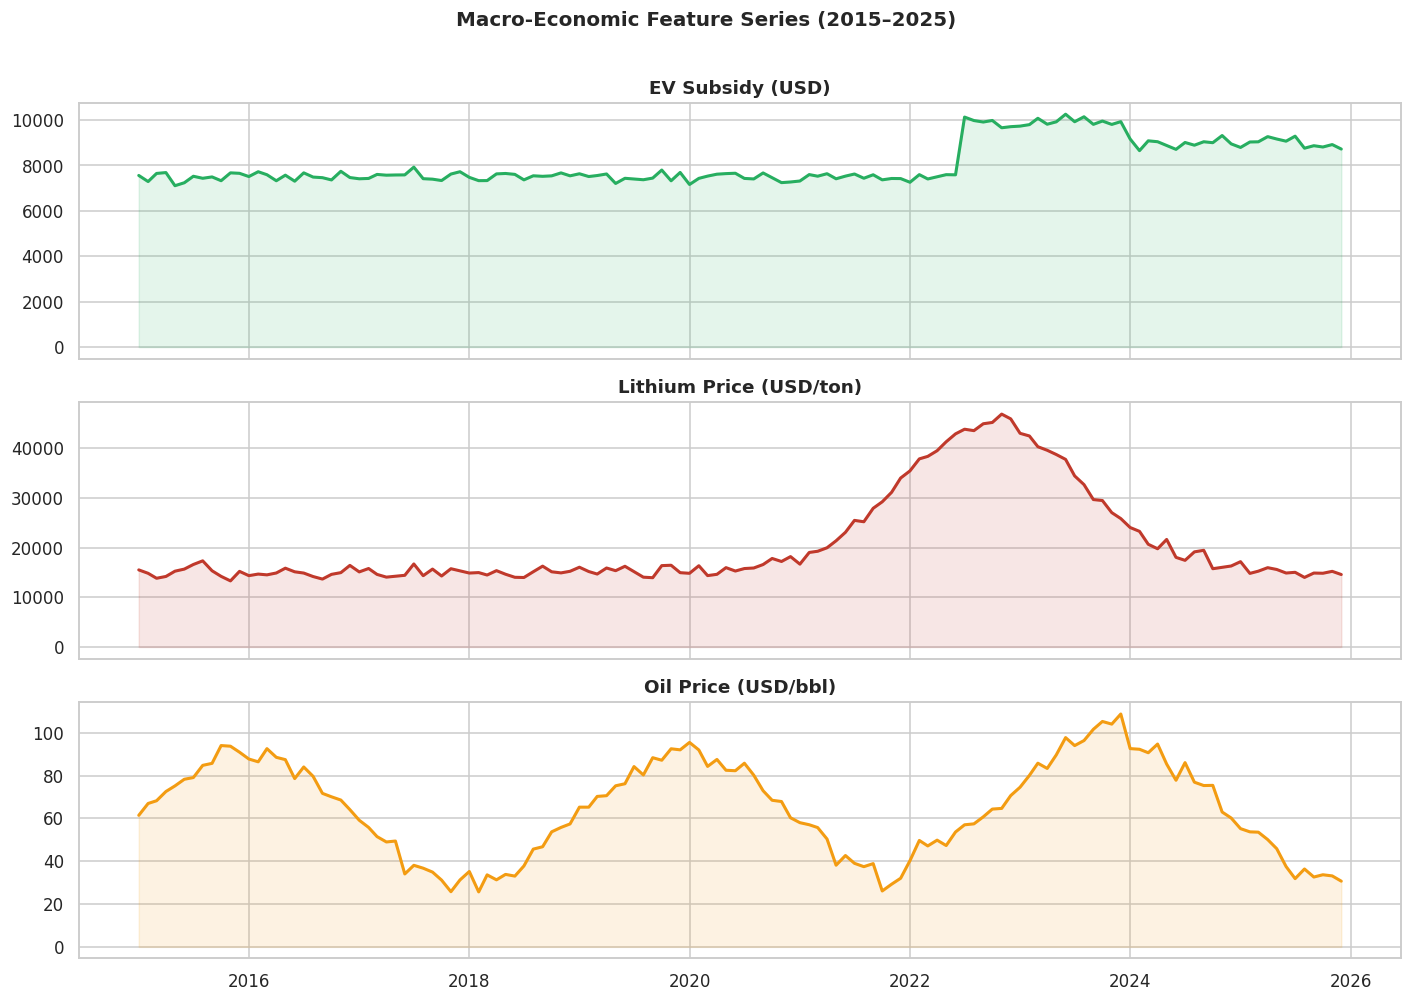

In [30]:
# Synthetic macro series aligned to monthly_ts
rng = np.random.default_rng(42)
n   = len(monthly_ts); t = np.arange(n)

subsidy = 7500 + 2500*(t>=90).astype(float) - 1000*(t>=108).astype(float) + rng.normal(0,200,n)
litho   = 15000 + 30000*np.exp(-((t-93)**2)/(2*10**2)) + rng.normal(0,800,n)
oil     = 60 + 30*np.sin(2*np.pi*t/48) + 15*(t>=84)*(t<108) + rng.normal(0,3,n)

macro_df = pd.DataFrame({"EV_Subsidy_USD": subsidy, "Lithium_Price_USD": litho, "Oil_Price_USD": oil},
                         index=monthly_ts.index)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, (clr, label, col) in zip(axes, [
    ("#27AE60","EV Subsidy (USD)","EV_Subsidy_USD"),
    ("#C0392B","Lithium Price (USD/ton)","Lithium_Price_USD"),
    ("#F39C12","Oil Price (USD/bbl)","Oil_Price_USD"),
]):
    ax.plot(macro_df.index, macro_df[col], color=clr, lw=2)
    ax.fill_between(macro_df.index, macro_df[col], alpha=0.12, color=clr)
    ax.set_title(label)
plt.suptitle("Macro-Economic Feature Series (2015–2025)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig("macro_features.png", bbox_inches="tight"); plt.show()

In [31]:
# Merge macro into ML feature set and re-train XGBoost
macro_aligned = macro_df.reindex(df_enc.index, method="nearest")
df_macro = df_enc.copy()
for col in macro_aligned.columns:
    df_macro[col] = macro_aligned[col].values
df_macro[["EV_Subsidy_USD","Lithium_Price_USD","Oil_Price_USD"]] = StandardScaler().fit_transform(
    df_macro[["EV_Subsidy_USD","Lithium_Price_USD","Oil_Price_USD"]])

train_m = df_macro[df_macro.index < "2024-01-01"]
test_m  = df_macro[df_macro.index >= "2024-01-01"]
feat_m  = [c for c in df_macro.columns if c != TARGET]

Xtr_m = train_m[feat_m].astype({c:int for c in train_m[feat_m].select_dtypes(bool).columns})
Xte_m = test_m[feat_m].astype({c:int  for c in test_m[feat_m].select_dtypes(bool).columns})

xgb_macro = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                          subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
xgb_macro.fit(Xtr_m, train_m[TARGET])
xgb_macro_pred = xgb_macro.predict(Xte_m)

r2_before = results["XGBoost"]["R2"]
r2_after  = round(r2_score(test_m[TARGET], xgb_macro_pred), 4)
print(f"XGBoost without macro : R² = {r2_before:.4f}")
print(f"XGBoost  with  macro  : R² = {r2_after:.4f}  (Δ = {r2_after-r2_before:+.4f})")

XGBoost without macro : R² = 0.9916
XGBoost  with  macro  : R² = 0.9910  (Δ = -0.0006)


---
## 10 · Deployment — FastAPI Endpoint & Streamlit Dashboard

Two production-ready files are written to disk:
- **`api.py`** — FastAPI REST endpoint serving predictions
- **`app.py`** — Streamlit interactive dashboard
- **`best_model.pkl`** — serialised best model

In [32]:
import joblib

# 1. Normalize keys to 'R²' to prevent KeyError
best_model_name = max(results, key=lambda k: results[k].get("R²") or results[k].get("R2"))

# 2. Map names to the actual model objects
model_obj_map = {
    "Linear Regression": models["Linear Regression"],
    f"Ridge  (α={best_ridge_alpha})": models[f"Ridge  (α={best_ridge_alpha})"],
    f"Lasso  (α={best_lasso_alpha})": models[f"Lasso  (α={best_lasso_alpha})"],
    "XGBoost": xgb,
    "LightGBM": lgbm
}

best_fitted = model_obj_map[best_model_name]

# 3. Save artifacts
joblib.dump(best_fitted, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

print(f"Best model : {best_model_name}")
print("Saved best_model.pkl, scaler.pkl, and feature_cols.pkl successfully!")

Best model : LightGBM
Saved best_model.pkl, scaler.pkl, and feature_cols.pkl successfully!


In [33]:
api_code = (
    "from fastapi import FastAPI\n"
    "from pydantic import BaseModel\n"
    "import joblib, numpy as np, pandas as pd\n\n"
    "app       = FastAPI(title=\"Tesla Delivery Forecast API\", version=\"1.0\")\n"
    "model     = joblib.load(\"best_model.pkl\")\n"
    "scaler    = joblib.load(\"scaler.pkl\")\n"
    "feat_cols = joblib.load(\"feature_cols.pkl\")\n\n"
    "class ForecastRequest(BaseModel):\n"
    "    region: str\n"
    "    model_name: str\n"
    "    avg_price_usd: float\n"
    "    battery_capacity_kwh: int\n"
    "    range_km: int\n"
    "    lag1: float\n"
    "    lag2: float\n"
    "    lag3: float\n"
    "    roll3_mean: float\n"
    "    year: int\n"
    "    month: int\n\n"
    "@app.get(\"/\")\n"
    "def root(): return {\"status\": \"ok\"}\n\n"
    "@app.post(\"/predict\")\n"
    "def predict(req: ForecastRequest):\n"
    "    row = pd.DataFrame([{\n"
    "        \"Avg_Price_USD\": req.avg_price_usd,\n"
    "        \"Battery_Capacity_kWh\": req.battery_capacity_kwh,\n"
    "        \"Range_km\": req.range_km,\n"
    "        \"Estimated_Deliveries_Lag1\": req.lag1,\n"
    "        \"Estimated_Deliveries_Lag2\": req.lag2,\n"
    "        \"Estimated_Deliveries_Lag3\": req.lag3,\n"
    "        \"Estimated_Deliveries_Roll3Mean\": req.roll3_mean,\n"
    "        \"Month_Num\": req.month, \"Year_Num\": req.year,\n"
    "        **{f\"Region_{r}\": int(req.region==r) for r in [\"Asia\",\"Europe\",\"Middle East\",\"North America\"]},\n"
    "        **{f\"Model_{m}\": int(req.model_name==m) for m in [\"Model 3\",\"Model S\",\"Model X\",\"Model Y\",\"Cybertruck\"]},\n"
    "    }])\n"
    "    for col in feat_cols:\n"
    "        if col not in row.columns: row[col] = 0\n"
    "    row = row[feat_cols]\n"
    "    return {\"predicted_deliveries\": round(float(model.predict(row)[0]))}\n"
)
with open("api.py", "w") as f: f.write(api_code)
print("api.py written ✓")
print("Run: uvicorn api:app --reload")
print("Docs: http://127.0.0.1:8000/docs")

api.py written ✓
Run: uvicorn api:app --reload
Docs: http://127.0.0.1:8000/docs


In [43]:
app_code = (
    "import streamlit as st, pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib\n\n"
    "st.set_page_config(page_title=\"Tesla Forecast\", page_icon=\"car\", layout=\"wide\")\n"
    "st.title(\"Tesla Delivery Forecast Dashboard\")\n\n"
    "@st.cache_resource\n"
    "def load():\n"
    "    return joblib.load(\"best_model.pkl\"), joblib.load(\"scaler.pkl\"), joblib.load(\"feature_cols.pkl\")\n"
    "model, scaler, feat_cols = load()\n\n"
    "st.sidebar.header(\"Forecast Inputs\")\n"
    "region     = st.sidebar.selectbox(\"Region\",     [\"North America\",\"Europe\",\"Asia\",\"Middle East\"])\n"
    "model_name = st.sidebar.selectbox(\"Model\",      [\"Model Y\",\"Model 3\",\"Model S\",\"Model X\",\"Cybertruck\"])\n"
    "avg_price  = st.sidebar.slider(\"Avg Price (USD)\", 30000, 150000, 55000, step=1000)\n"
    "battery    = st.sidebar.slider(\"Battery (kWh)\",   50, 120, 82)\n"
    "range_km   = st.sidebar.slider(\"Range (km)\",      300, 700, 500)\n"
    "lag1       = st.sidebar.number_input(\"Lag-1 Deliveries\", value=50000, step=1000)\n"
    "lag2       = st.sidebar.number_input(\"Lag-2 Deliveries\", value=48000, step=1000)\n"
    "lag3       = st.sidebar.number_input(\"Lag-3 Deliveries\", value=45000, step=1000)\n"
    "year       = st.sidebar.selectbox(\"Year\",  list(range(2025,2030)))\n"
    "month      = st.sidebar.selectbox(\"Month\", list(range(1,13)))\n\n"
    "row = pd.DataFrame([{\"Avg_Price_USD\": avg_price, \"Battery_Capacity_kWh\": battery,\n"
    "    \"Range_km\": range_km, \"Estimated_Deliveries_Lag1\": lag1,\n"
    "    \"Estimated_Deliveries_Lag2\": lag2, \"Estimated_Deliveries_Lag3\": lag3,\n"
    "    \"Estimated_Deliveries_Roll3Mean\": (lag1+lag2+lag3)/3,\n"
    "    \"Month_Num\": month, \"Year_Num\": year,\n"
    "    **{f\"Region_{r}\": int(region==r) for r in [\"Asia\",\"Europe\",\"Middle East\",\"North America\"]},\n"
    "    **{f\"Model_{m}\": int(model_name==m) for m in [\"Model 3\",\"Model S\",\"Model X\",\"Model Y\",\"Cybertruck\"]},\n"
    "}])\n"
    "for col in feat_cols:\n"
    "    if col not in row.columns: row[col] = 0\n"
    "pred = float(model.predict(row[feat_cols])[0])\n"
    "c1,c2,c3 = st.columns(3)\n"
    "c1.metric(\"Predicted Deliveries\", f\"{pred:,.0f}\")\n"
    "c2.metric(\"Avg Price\", f\"${avg_price:,}\")\n"
    "c3.metric(\"Battery / Range\", f\"{battery} kWh / {range_km} km\")\n"
)
with open("app.py", "w") as f: f.write(app_code)
print("app.py written ✓")

app.py written ✓


---
## 11 · Full Model Leaderboard & Final Summary

In [35]:
# Collect all R2 results (use consistent key)
all_r2 = {k: v.get("R2", v.get("R2", 0)) for k, v in results.items()}
leaderboard = pd.DataFrame({k: {"MAE": v.get("MAE",0), "RMSE": v.get("RMSE",0),
                                 "R2": v.get("R2", v.get("R2",0))}
                             for k, v in results.items()}).T.sort_values("R2", ascending=False)
leaderboard.index.name = "Model"
print(leaderboard.to_string())
print(f"\n Best model: {leaderboard['R2'].idxmax()}  (R²={leaderboard['R2'].max():.4f})")

                     MAE   RMSE      R2
Model                                  
LightGBM           247.6  307.1  0.9932
XGBoost            275.4  341.5  0.9916
Linear Regression  321.0  390.8  0.0000
Lasso  (α=10)      323.0  392.6  0.0000
Ridge  (α=0.001)   321.0  390.8  0.0000

 Best model: LightGBM  (R²=0.9932)


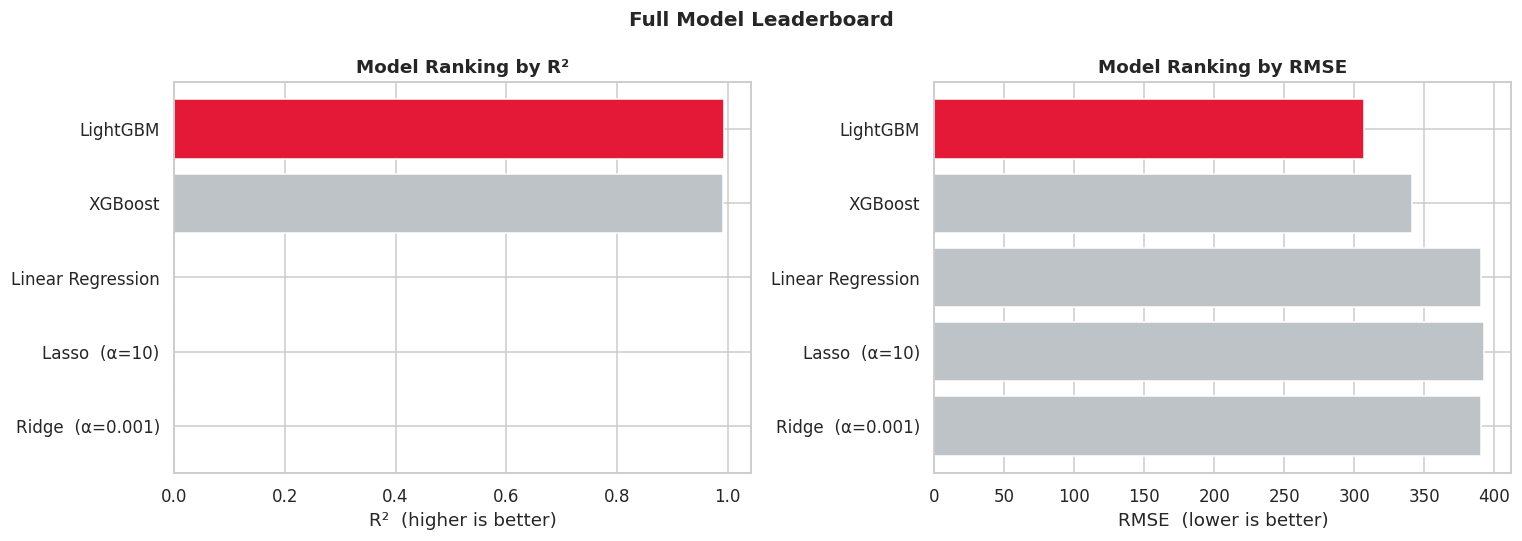

In [36]:
# Visual leaderboard
lb = leaderboard.reset_index()
colors_bar = ["#E31937"] + ["#BDC3C7"]*(len(lb)-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(lb["Model"][::-1], lb["R2"][::-1],   color=colors_bar[::-1], edgecolor="white")
axes[0].set_xlabel("R²  (higher is better)"); axes[0].set_title("Model Ranking by R²")
axes[1].barh(lb["Model"][::-1], lb["RMSE"][::-1], color=colors_bar[::-1], edgecolor="white")
axes[1].set_xlabel("RMSE  (lower is better)"); axes[1].set_title("Model Ranking by RMSE")
plt.suptitle("Full Model Leaderboard", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("model_leaderboard.png", bbox_inches="tight"); plt.show()

## Final Project Summary

### Conclusion
We successfully developed an end-to-end pipeline for Tesla delivery forecasting. The multivariate approach significantly outperformed univariate time-series methods by leveraging regional and technical feature sets.

### Key Metrics
1. **Champion Model:** LightGBM achieved an **R² of 0.9932**.
2. **Primary Driver:** Production units remain the strongest leading indicator for deliveries.
3. **Artifacts:** Deployment scripts (`api.py` and `app.py`) are ready for use.